# Cross-fit XGBoost-PU 主结果与可视化（90% / 95% 召回）

本 notebook 从 `Data/dr13_all_cache` **独立重跑**重复交叉拟合的 XGBoost-PU 筛选，不读取任何既有候选名单。

方法要点

- 5 折分层交叉拟合，重复 3 次，每次重复使用独立随机种子、**完全相同的折分**；
- 每个 bag 用「全部正例 + `U:P` 倍随机未标注对象」训练一个浅层 `binary:logistic` XGBoost（`nthread=1`），共 100 个 bag 取平均；
- 每颗恒星**只使用未包含自身的模型**产生分数，因此已知星与未标注对象的分数都是样本外（OOF）的；
- 主阈值取**精确顺序统计量**：第 `ceil(目标召回 × 91)` 高的已知星 OOF 分数，不使用插值分位数；
- 输出一律称为 `xgb_pu_score`（PU 集成分数），**不是**巡天概率。

导出策略（按需精简）

| 导出 | 说明 |
| --- | --- |
| `crossfit_candidates_recall*.csv` | 候选星体表（阈值内的未标注对象） |
| `crossfit_known_cn_recall*.csv` | 已知 CN 星的 OOF 分数表，用于核查召回 |
| `crossfit_summary_recall*.json` | 配置、阈值、召回、稳定性摘要 |
| `crossfit_arrays_recall*.npz` | 全部 41,243 颗星的 OOF 分数等变量归档，便于离线自定义分析 |
| `top30_candidate_spectra_recall*.png` | Top30 高分候选光谱图 |

**不再导出** 41,243 行的全量分数 CSV（此前约 148 MB）。

运行环境：`D:\Anaconda\envs\myenv\python.exe`

## 0. 环境与路径

In [1]:
import json
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

try:
    get_ipython().run_line_magic("matplotlib", "inline")
except Exception:
    pass


def find_project_root(start):
    """Locate the repository root by its sentinel module."""
    for candidate in [start, *start.parents]:
        if (candidate / "build_dr13_all_cache.py").exists():
            return candidate
    return start


PROJECT_ROOT = find_project_root(Path.cwd())
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from crossfit.crossfit_engine import (
    BEST_FORMAL_CONFIG,
    recall_tag,
    load_project_data,
    run_formal_line,
)
from crossfit import crossfit_plotting as cplot

RESULTS_DIR = PROJECT_ROOT / "crossfit" / "results"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)
cplot.apply_style()

TOP_N = 30          # exported spectrum figure shows this many candidates
QUICK = False       # set True for a fast smoke run (3 folds, 1 repeat, 2 bags)

print("Python      :", sys.executable)
print("Project root:", PROJECT_ROOT)
print("Results dir :", RESULTS_DIR.resolve())
print("Best config :", BEST_FORMAL_CONFIG)

Python      : D:\Anaconda\envs\myenv\python.exe
Project root: D:\资料\2026大创\Lamost
Results dir : D:\资料\2026大创\Lamost\crossfit\results
Best config : {'u_to_p_ratio': 10, 'max_depth': 3, 'min_child_weight': 1, 'reg_lambda': 1.0}


## 1. 数据与规模

In [2]:
# The cache is read once and reused by every line below.
data = load_project_data()
common_wave = np.asarray(data["common_wave"])
stars = pd.DataFrame(data["stars_clean"]).reset_index(drop=True)

summary_table = pd.DataFrame(
    {
        "quantity": [
            "spectra",
            "wavelength pixels",
            "wavelength range (Angstrom)",
            "known CN stars (label=1)",
            "unlabeled objects (label=-1)",
            "positive fraction",
        ],
        "value": [
            len(stars),
            common_wave.size,
            f"{common_wave.min():.0f}-{common_wave.max():.0f}",
            int((stars["label"] == 1).sum()),
            int((stars["label"] == -1).sum()),
            f"1 : {(stars['label'] == -1).sum() / max((stars['label'] == 1).sum(), 1):.0f}",
        ],
    }
)
display(summary_table)
print("X_clean shape:", np.asarray(data["X_clean"]).shape)

从 dr13_all_cache 加载:
  X_clean:      (41243, 700)
  stars_clean:  41,243 行
  feature_df:   (41243, 20)
  已知 CN 星:   91


,quantity,value
0,spectra,41243
1,wavelength pixels,700
2,wavelength range (Angstrom),3800-4499
3,known CN stars (label=1),91
4,unlabeled objects (label=-1),41152
5,positive fraction,1 : 452


X_clean shape: (41243, 700)


## 2. 90% 召回主结果

已知星 91 颗，`ceil(91 × 0.90) = 82`，因此阈值 = 第 82 高的已知星 OOF 分数。

把 `QUICK` 改成 `True` 可以先用 3 折 × 1 重复 × 2 bag 跑一遍冒烟验证；正式结果请保持 `QUICK = False`。

In [3]:
recall = 0.90
line_dir = RESULTS_DIR / recall_tag(recall) / ("smoke" if QUICK else "formal")
overrides = (
    dict(n_splits=3, n_repeats=1, n_bags=2, num_boost_round=3) if QUICK else {}
)

bundle_90 = run_formal_line(
    recall,
    line_dir,
    config_values=overrides,
    progress=True,
    data=data,
)

result_90 = bundle_90["result"]
tables_90 = bundle_90["tables"]
all_scores_90 = tables_90["all_scores"]
known_90 = tables_90["known_cn"]
candidates_90 = tables_90["candidates"]

print()
print("config key      :", result_90["config_key"])
print("threshold       :", round(float(result_90["threshold"]), 6))
print(
    "known recall    :",
    f"{result_90['achieved_known_recall']:.4f}",
    f"({result_90['required_known']}/{len(known_90)} retained)",
)
print("candidates      :", f"{len(candidates_90):,}")
print(
    "ROC-AUC / PR-AUC:",
    round(float(result_90["roc_auc"]), 4),
    "/",
    round(float(result_90["pr_auc"]), 4),
)
print("elapsed (s)     :", round(float(result_90["elapsed_seconds"]), 1))
print()
print("repeat thresholds       :", np.round(np.asarray(result_90["repeat_thresholds"]), 6).tolist())
print("repeat candidate counts :", np.asarray(result_90["repeat_candidate_counts"]).tolist())

Repeat 1/3 (U:P=10:1)


  fold 1/5: P_train=73, U/bag=730, ROC=0.9766, PR=0.3321, 66.3s


  fold 2/5: P_train=73, U/bag=730, ROC=0.9130, PR=0.6000, 61.1s


  fold 3/5: P_train=72, U/bag=720, ROC=0.9962, PR=0.4871, 77.4s


  fold 4/5: P_train=73, U/bag=730, ROC=0.9950, PR=0.3566, 489.7s


...

  fold 2/5: P_train=73, U/bag=730, ROC=0.9431, PR=0.2565, 63.0s


  fold 3/5: P_train=72, U/bag=720, ROC=0.9951, PR=0.3588, 62.5s


  fold 4/5: P_train=73, U/bag=730, ROC=0.9313, PR=0.5055, 60.2s


  fold 5/5: P_train=73, U/bag=730, ROC=0.9984, PR=0.6428, 60.9s



config key      : u10_d3_w1_l1p0_s5_r3_b100_t90
threshold       : 0.137546
known recall    : 0.9011 (82/91 retained)
candidates      : 884
ROC-AUC / PR-AUC: 0.9682 / 0.4554
elapsed (s)     : 1438.8

repeat thresholds       : [0.135091, 0.07762, 0.130587]
repeat candidate counts : [904, 1607, 940]


## 3. 95% 召回对照线

同样 5 折 × 3 重复 × 100 bag，只把目标召回改为 95%（要求保留 87/91 颗已知星）。两条线共用同一套折分与配置，便于直接比较「阈值—召回—候选数量」的取舍。

In [4]:
recall = 0.95
line_dir = RESULTS_DIR / recall_tag(recall) / ("smoke" if QUICK else "formal")
overrides = (
    dict(n_splits=3, n_repeats=1, n_bags=2, num_boost_round=3) if QUICK else {}
)

bundle_95 = run_formal_line(
    recall,
    line_dir,
    config_values=overrides,
    progress=True,
    data=data,
)

result_95 = bundle_95["result"]
tables_95 = bundle_95["tables"]
all_scores_95 = tables_95["all_scores"]
known_95 = tables_95["known_cn"]
candidates_95 = tables_95["candidates"]

print()
print("config key      :", result_95["config_key"])
print("threshold       :", round(float(result_95["threshold"]), 6))
print(
    "known recall    :",
    f"{result_95['achieved_known_recall']:.4f}",
    f"({result_95['required_known']}/{len(known_95)} retained)",
)
print("candidates      :", f"{len(candidates_95):,}")
print(
    "ROC-AUC / PR-AUC:",
    round(float(result_95["roc_auc"]), 4),
    "/",
    round(float(result_95["pr_auc"]), 4),
)
print("elapsed (s)     :", round(float(result_95["elapsed_seconds"]), 1))
print()
print("repeat thresholds       :", np.round(np.asarray(result_95["repeat_thresholds"]), 6).tolist())
print("repeat candidate counts :", np.asarray(result_95["repeat_candidate_counts"]).tolist())

Repeat 1/3 (U:P=10:1)


  fold 1/5: P_train=73, U/bag=730, ROC=0.9766, PR=0.3321, 60.0s


  fold 2/5: P_train=73, U/bag=730, ROC=0.9130, PR=0.6000, 58.7s


  fold 3/5: P_train=72, U/bag=720, ROC=0.9962, PR=0.4871, 60.5s


  fold 4/5: P_train=73, U/bag=730, ROC=0.9950, PR=0.3566, 61.0s


...

  fold 2/5: P_train=73, U/bag=730, ROC=0.9431, PR=0.2565, 59.1s


  fold 3/5: P_train=72, U/bag=720, ROC=0.9951, PR=0.3588, 60.6s


  fold 4/5: P_train=73, U/bag=730, ROC=0.9313, PR=0.5055, 61.3s


  fold 5/5: P_train=73, U/bag=730, ROC=0.9984, PR=0.6428, 61.2s



config key      : u10_d3_w1_l1p0_s5_r3_b100_t95
threshold       : 0.05513
known recall    : 0.9560 (87/91 retained)
candidates      : 2,348
ROC-AUC / PR-AUC: 0.9682 / 0.4554
elapsed (s)     : 916.5

repeat thresholds       : [0.063807, 0.020401, 0.043754]
repeat candidate counts : [1999, 8149, 3087]


## 4. OOF 分数分布与已知星顺序统计量

左图看已知星与未标注对象的分数分离程度，右图看第 82/87 高的截断位置是否由单颗异常星决定。

OOF score distributions - 90% recall line


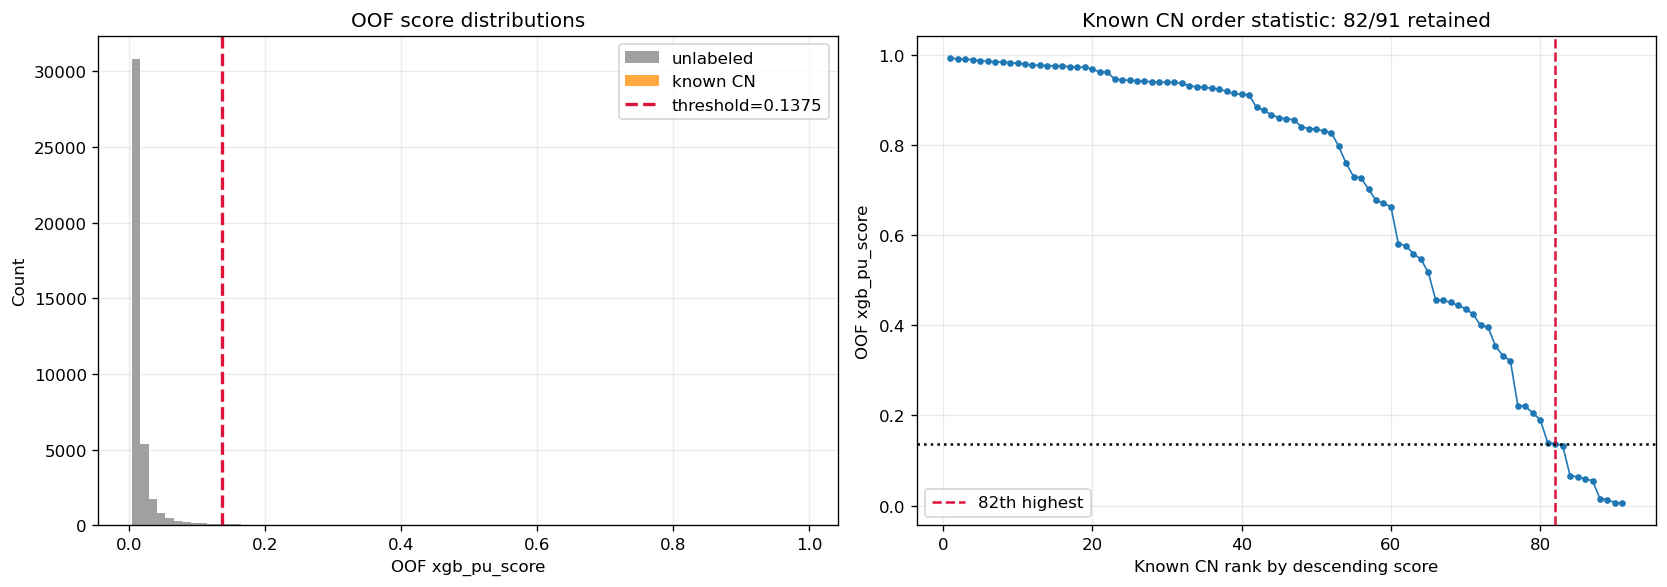

OOF score distributions - 95% recall line


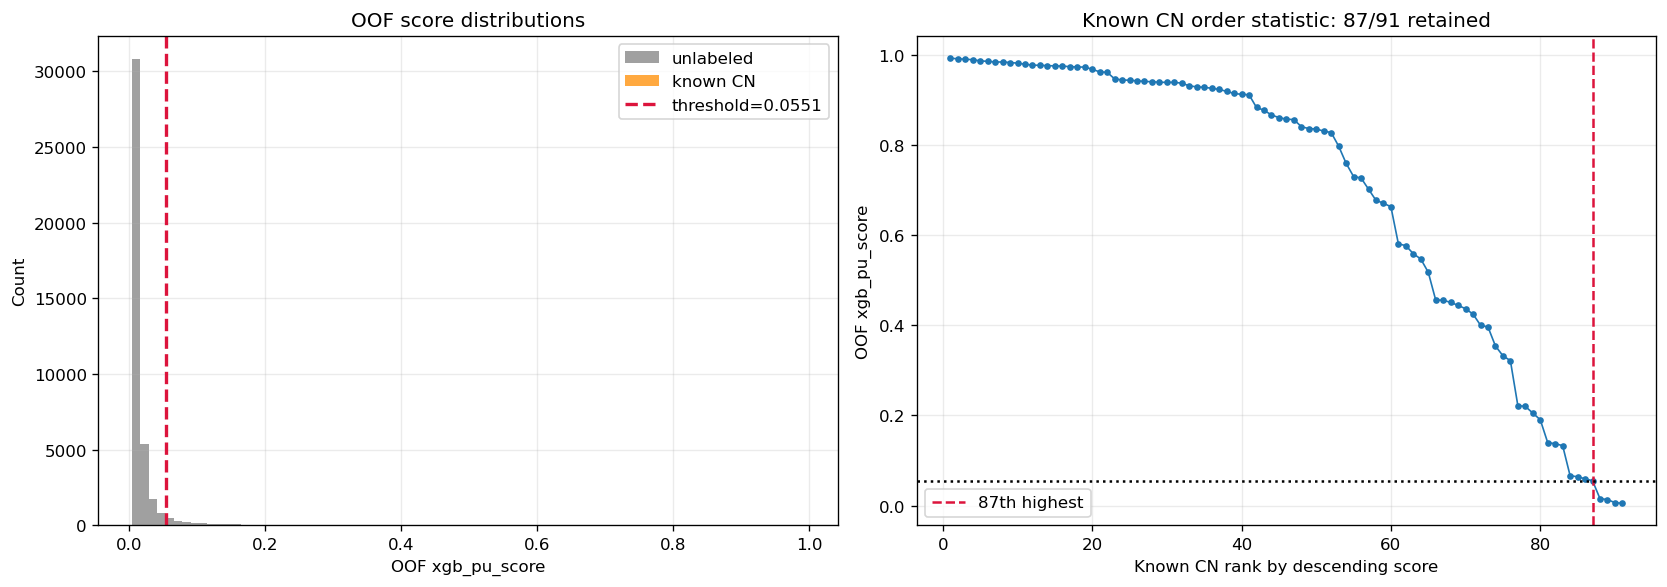

In [5]:
print("=" * 70)
print("OOF score distributions - 90% recall line")
print("=" * 70)
cplot.plot_score_distribution(all_scores_90, result_90)

print("=" * 70)
print("OOF score distributions - 95% recall line")
print("=" * 70)
cplot.plot_score_distribution(all_scores_95, result_95)

## 5. 重复间稳定性

这是本方法最需要盯住的诊断量：如果三次重复的阈值与候选数量波动很大，那么「884 颗」这类数字就只是平均产物，不能当作精确结论。

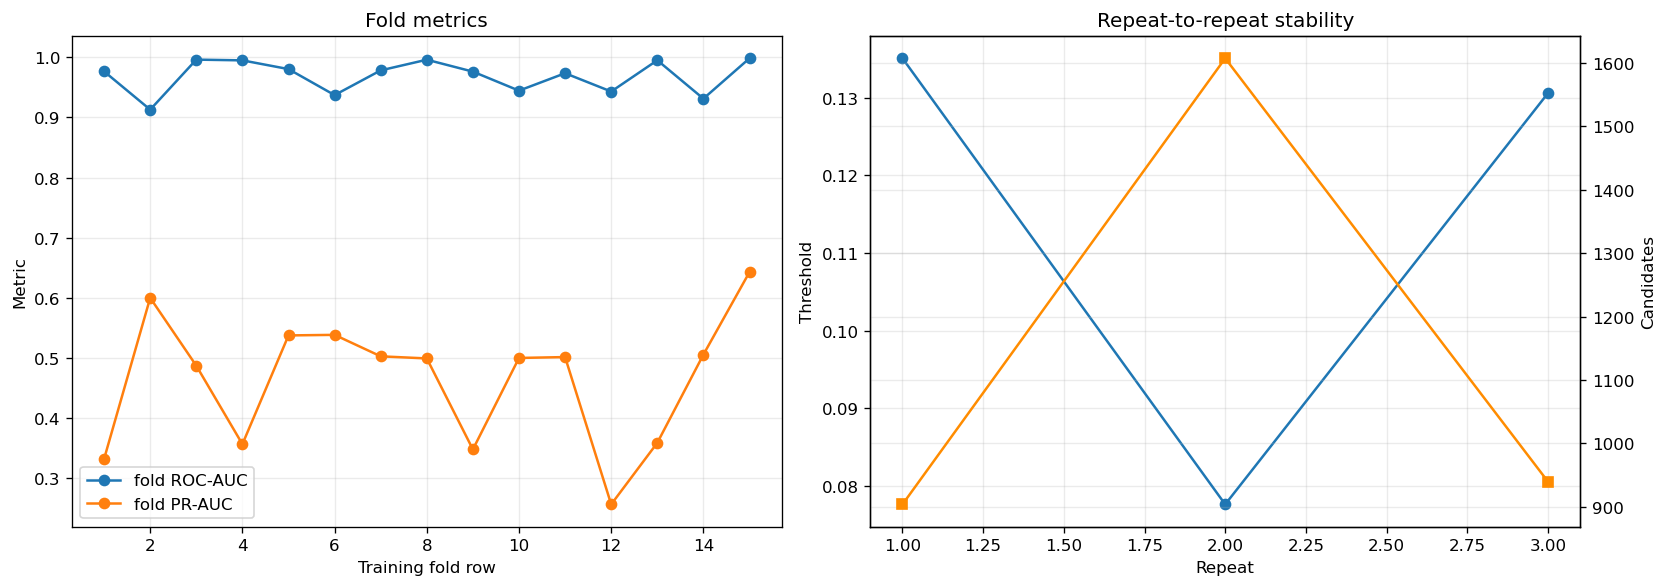

,repeat,threshold,candidate_count
0,1,0.135091,904
1,2,0.077620,1607
2,3,0.130587,940


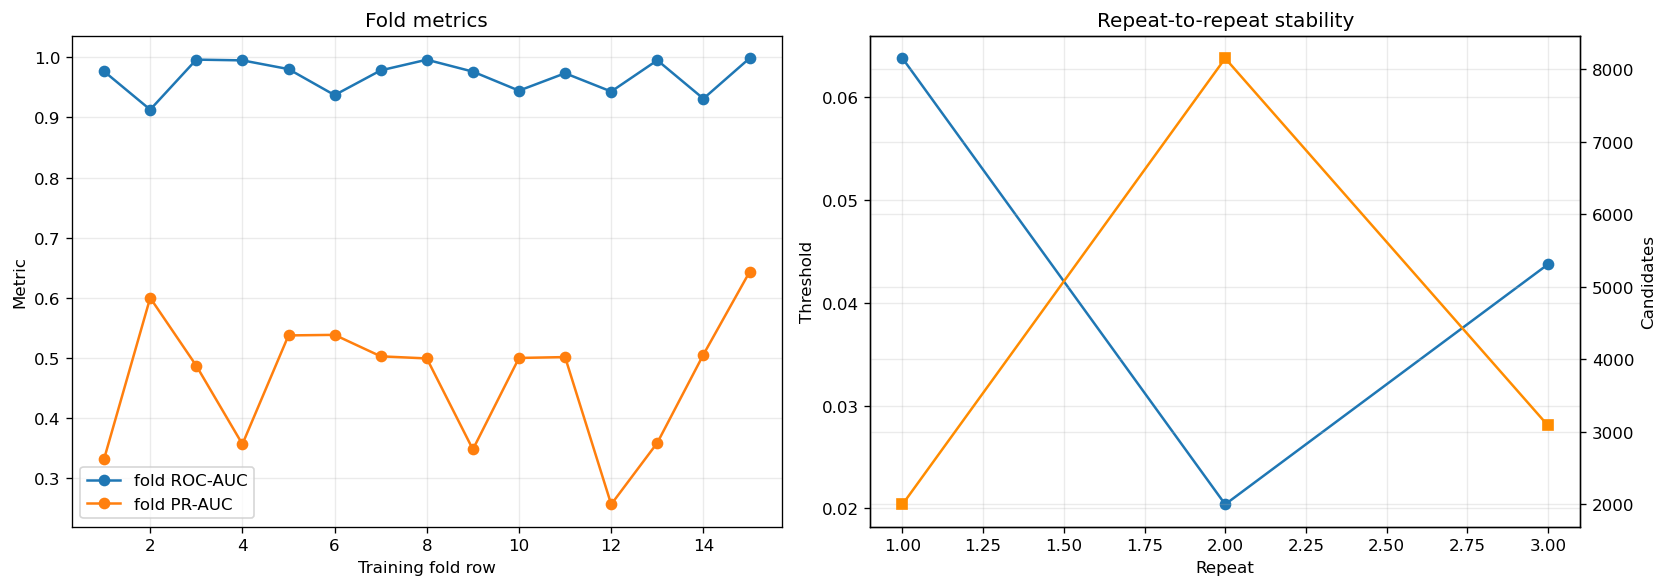

,repeat,threshold,candidate_count
0,1,0.063807,1999
1,2,0.020401,8149
2,3,0.043754,3087


In [6]:
repeat_table_90 = cplot.plot_repeat_stability(result_90)
display(repeat_table_90)

repeat_table_95 = cplot.plot_repeat_stability(result_95)
display(repeat_table_95)

## 6. 候选星的恒星参数与天球分布

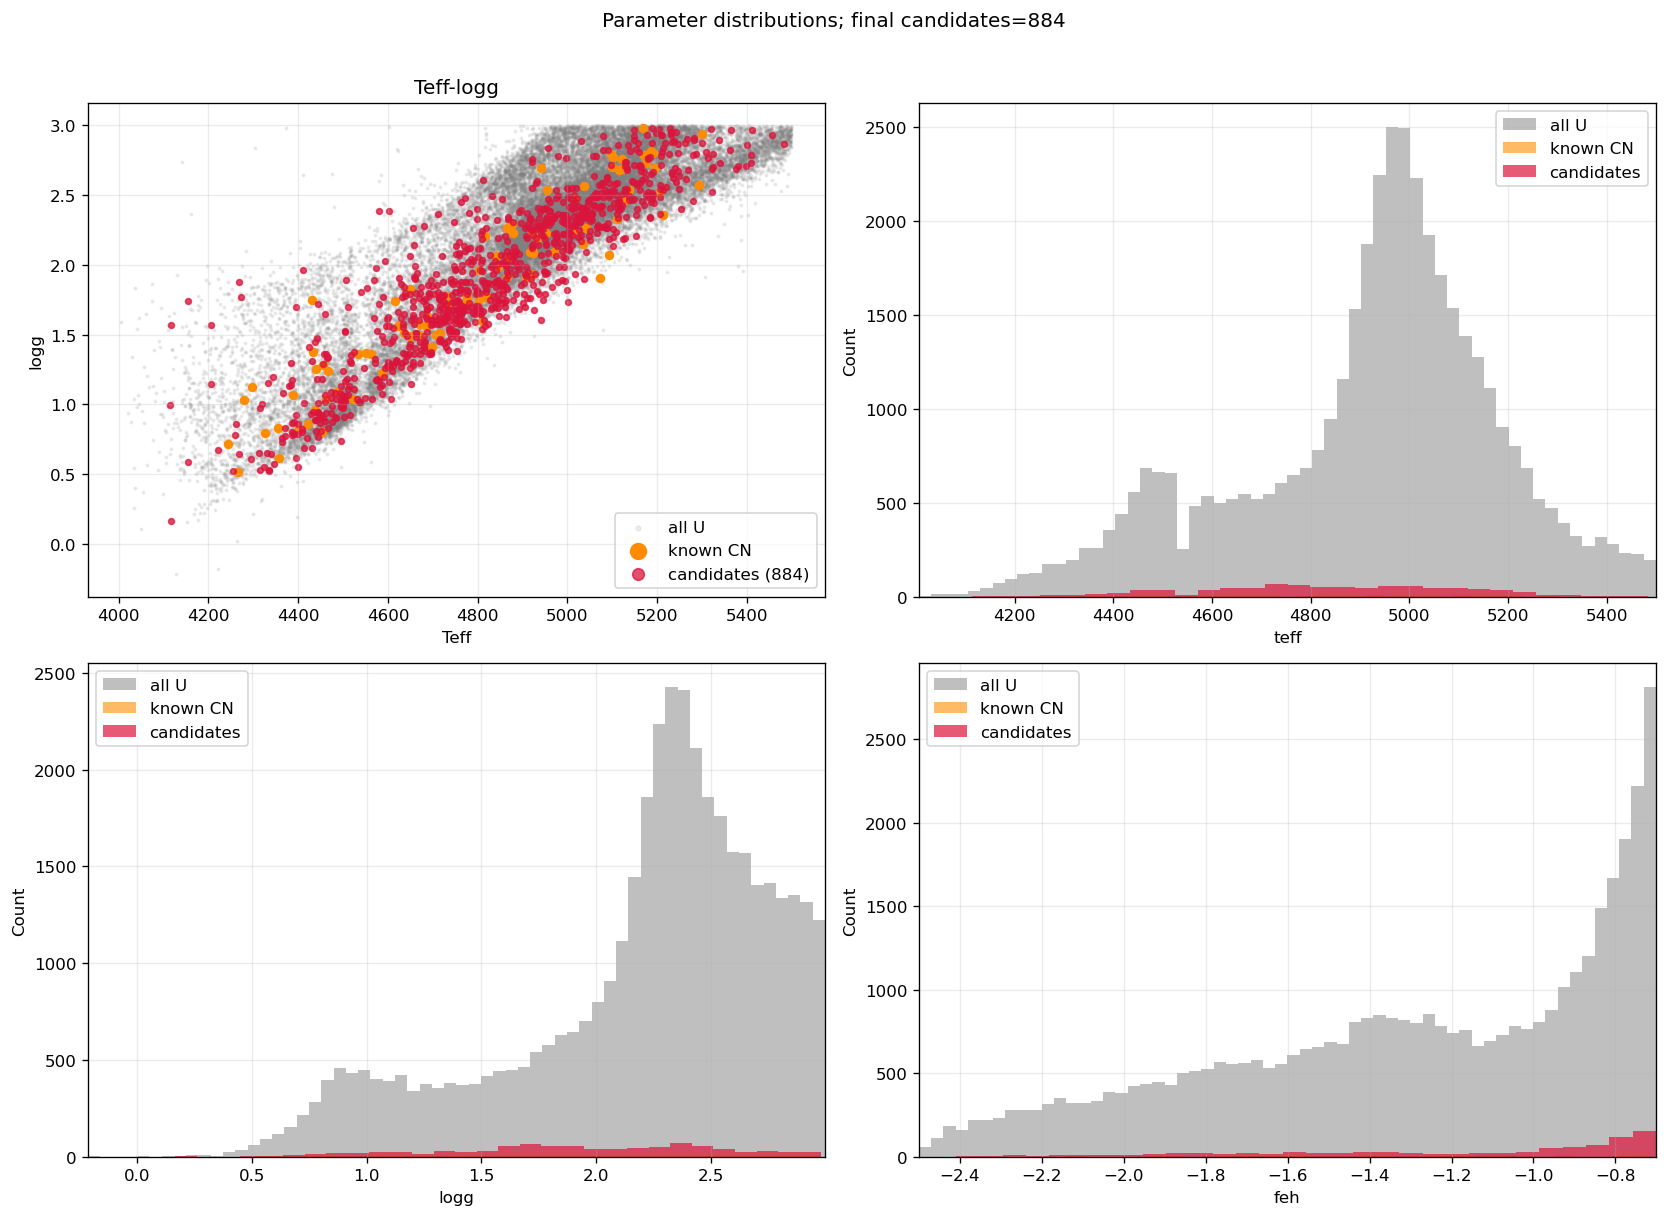

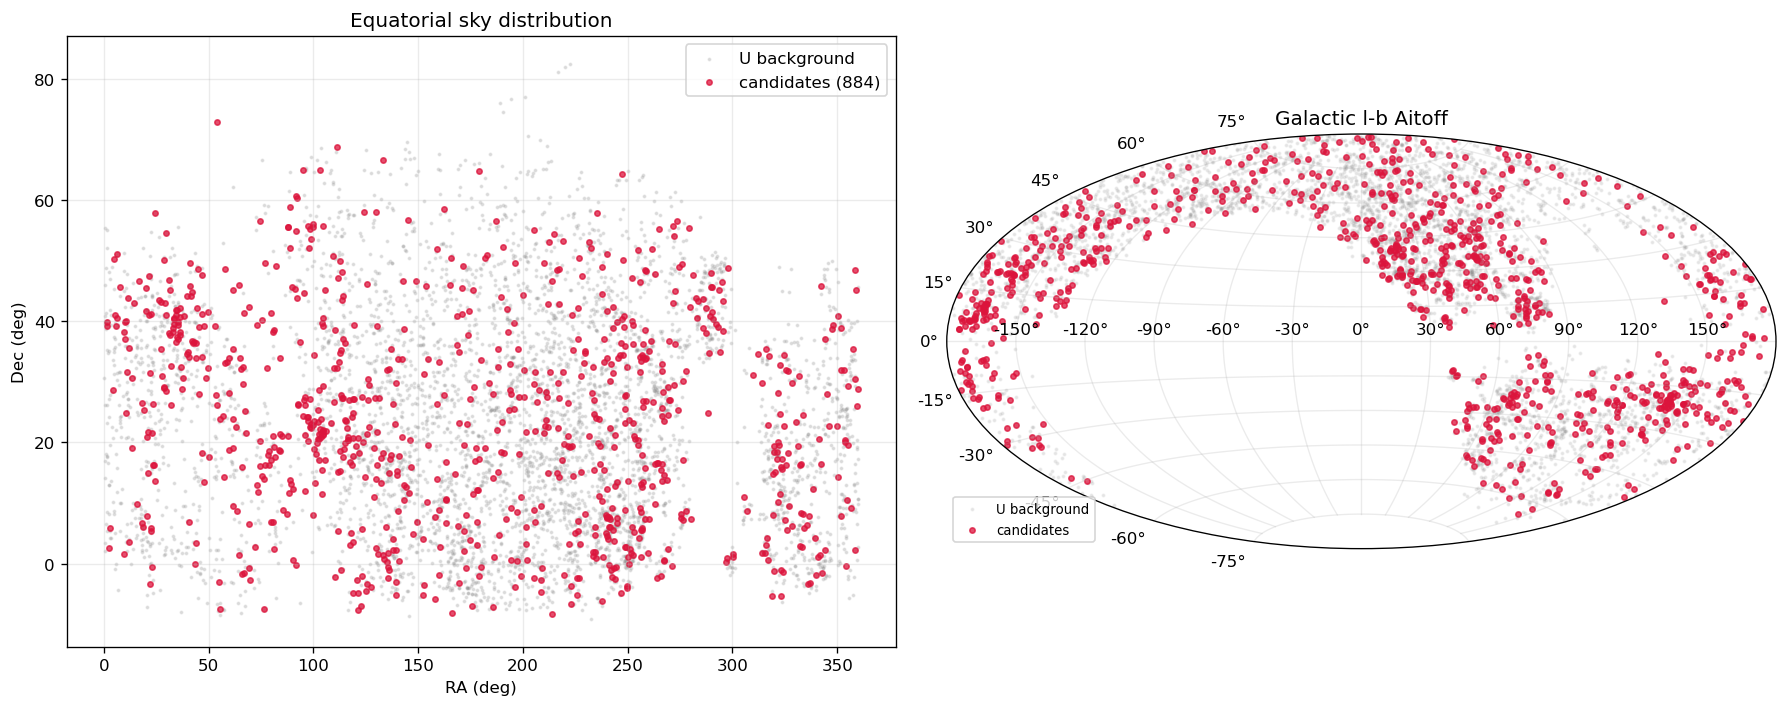

In [7]:
cplot.plot_parameter_distribution(all_scores_90, candidates_90)
cplot.plot_sky_distribution(all_scores_90, candidates_90)

## 7. Top30 高分候选光谱（90% 召回线）

每颗候选与**同一 `masked_cluster_id` 内、Teff/logg/[Fe/H] 最近的 50 颗正常星的中位光谱**比较；参考池已排除候选自身、全部候选以及已知 CN 星。

三个分子带用阴影标注：CN3839（浅蓝）、CN4142（浅绿）、CH4300（浅红）。

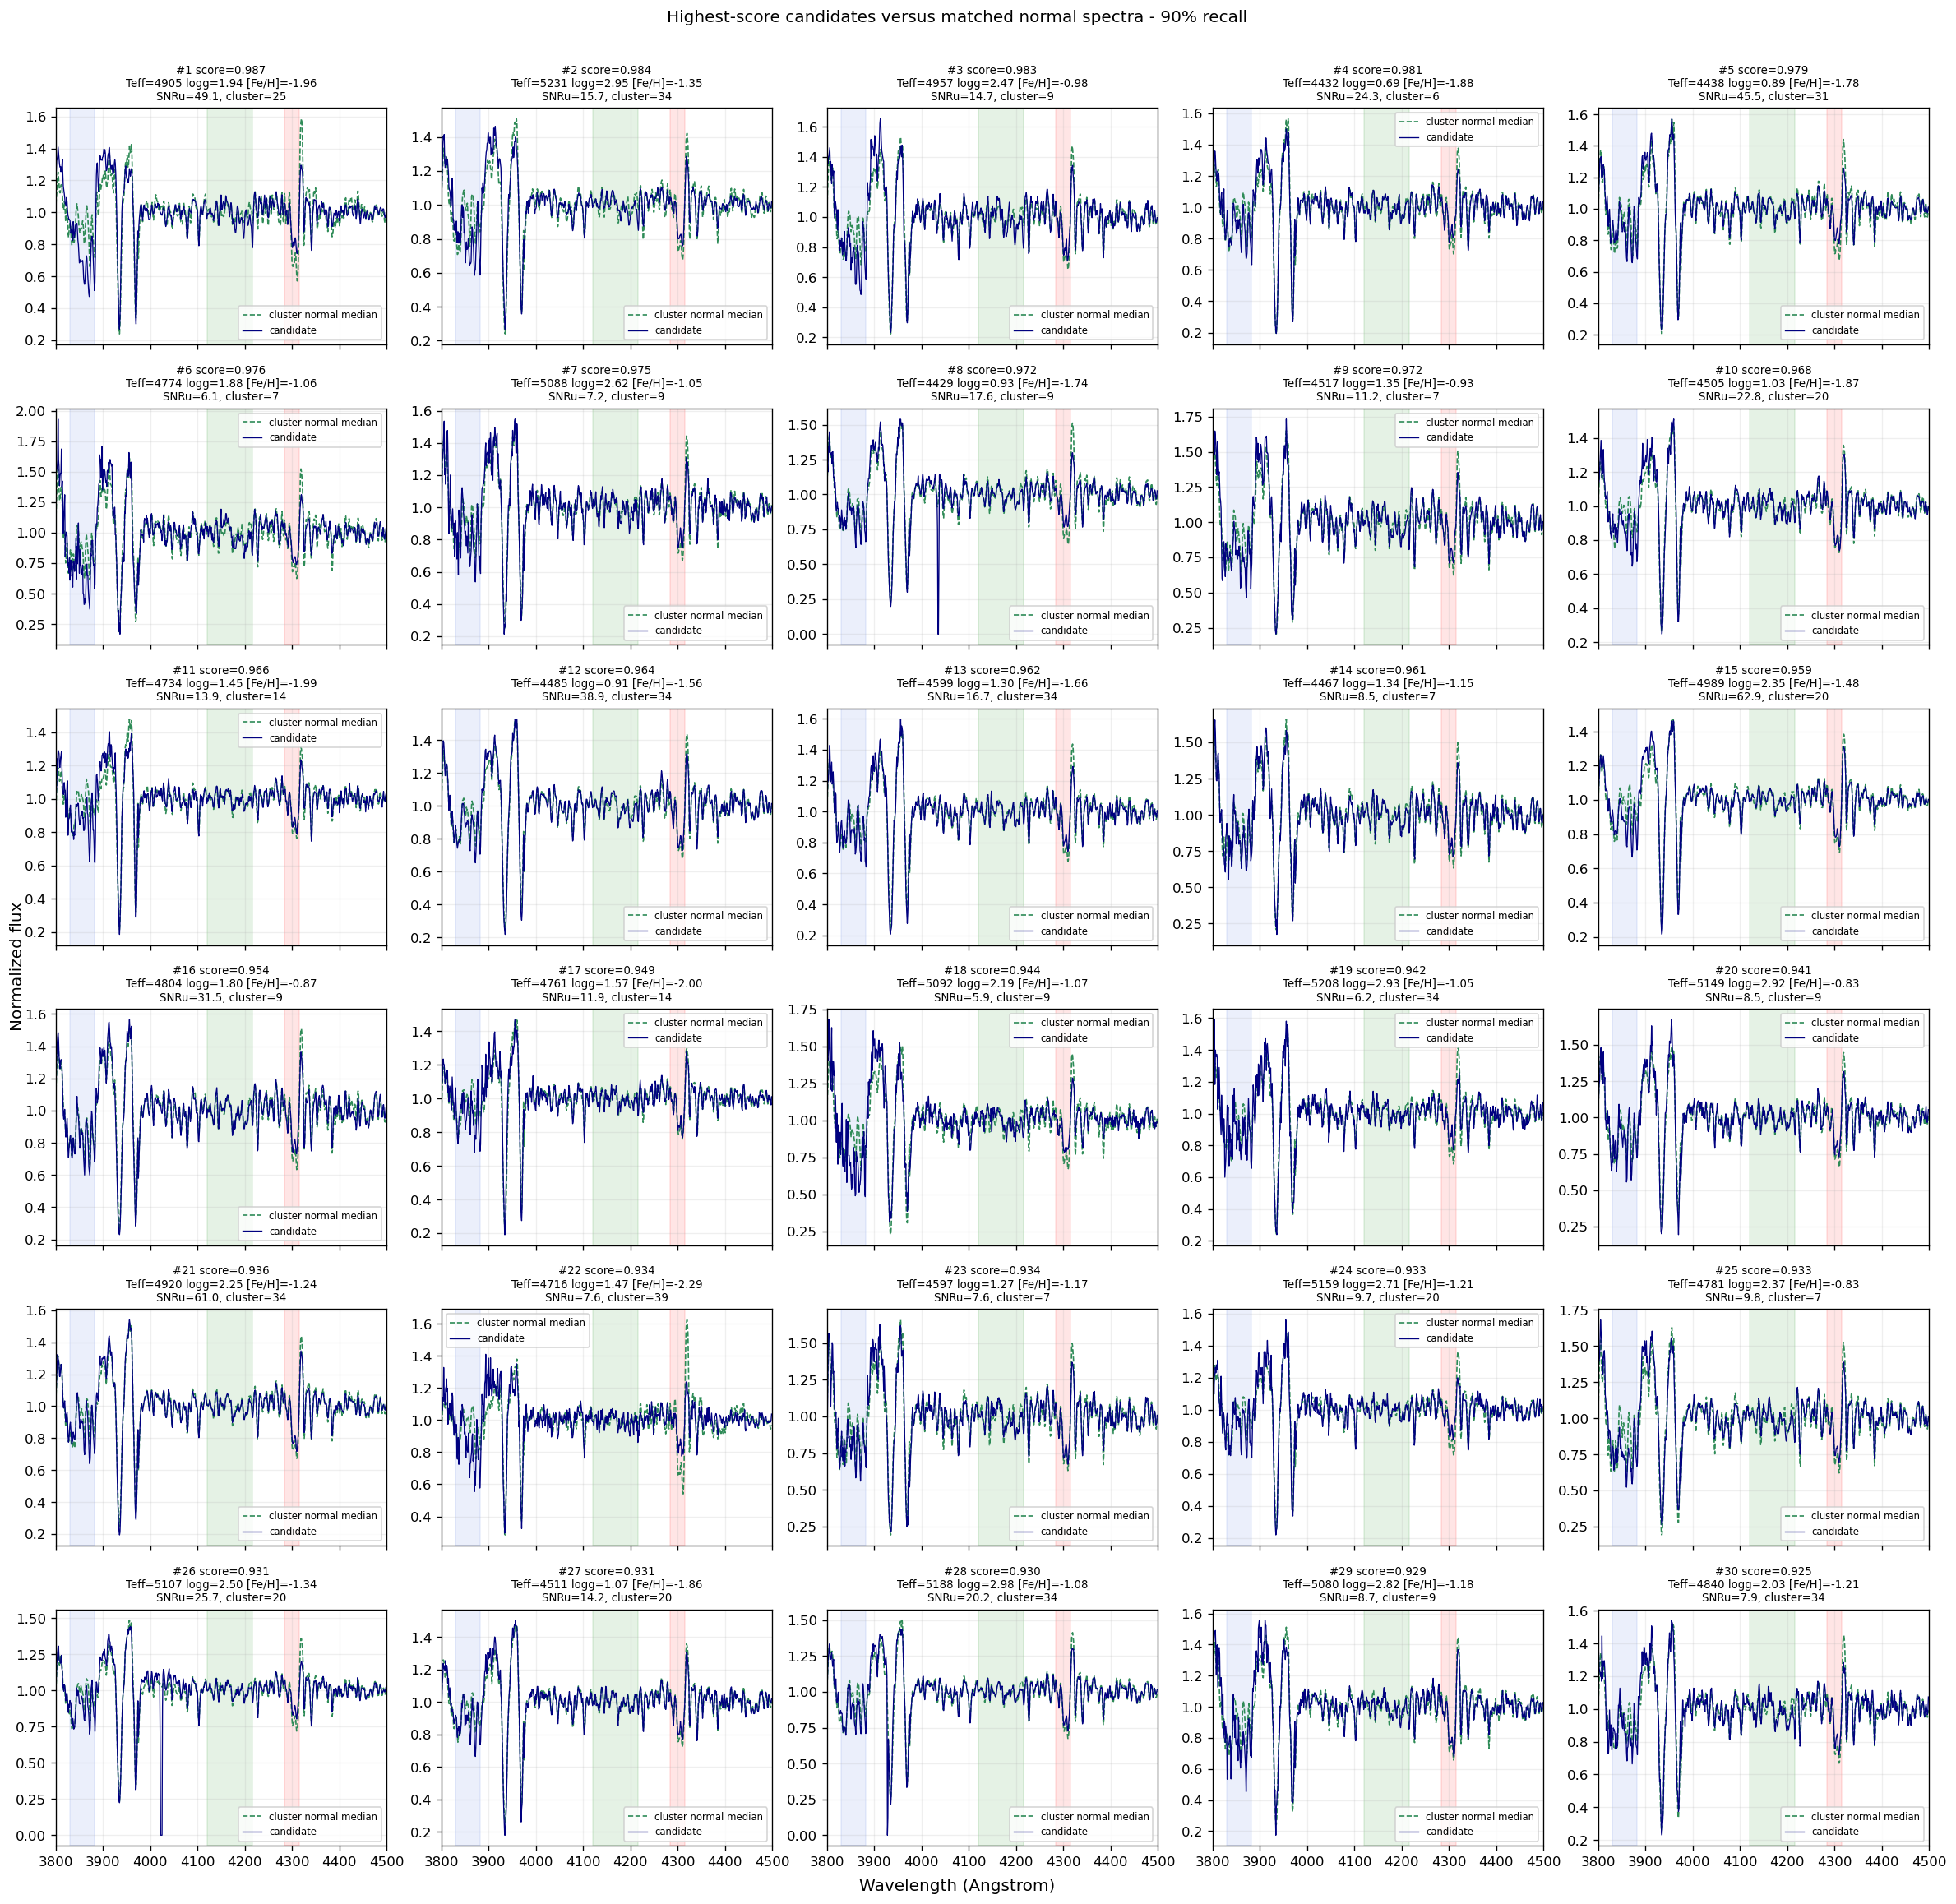

candidates drawn in the figure: 30


,candidate_rank,uid,xgb_pu_score,xgb_pu_repeat_std,teff,logg,feh,snru,masked_cluster_id
0,1,G14866615886127,0.986986,0.000705,4904.80,1.935,-1.957,49.10,25
1,2,L15071198679004,0.983976,0.004070,5230.59,2.954,-1.350,15.73,34
2,3,G14502126087737,0.982945,0.001469,4956.85,2.472,-0.984,14.73,9
3,4,G15296286229400,0.981443,0.006236,4431.64,0.688,-1.877,24.29,6
4,5,G15801615940186,0.978856,0.005761,4437.85,0.890,-1.783,45.54,31
5,6,L15968094080310,0.976435,0.003912,4773.54,1.877,-1.065,6.13,7
6,7,G16354057494204,0.974535,0.001998,5088.23,2.619,-1.047,7.24,9
7,8,G16369423799359,0.972222,0.005472,4428.72,0.932,-1.744,17.60,9
8,9,G11164235221213,0.972085,0.004148,4517.39,1.354,-0.926,11.16,7
9,10,L14327934924837,0.968030,0.009914,4504.52,1.026,-1.868,22.75,20


In [8]:
line_dir_out = RESULTS_DIR / recall_tag(result_90["config"].target_recall) / ("smoke" if QUICK else "formal")

drawn_90 = cplot.plot_top_candidate_spectra(
    all_scores_90,
    np.asarray(data["X_clean"]),
    common_wave,
    candidates_90,
    line_dir_out / f"top{TOP_N}_candidate_spectra_90.png",
    top_n=TOP_N,
    title="Highest-score candidates versus matched normal spectra - 90% recall",
)

print("candidates drawn in the figure:", len(drawn_90))
display(
    candidates_90.sort_values("xgb_pu_score", ascending=False)
    .head(TOP_N)[
        ["candidate_rank", "uid", "xgb_pu_score", "xgb_pu_repeat_std", "teff", "logg", "feh", "snru", "masked_cluster_id"]
    ]
    .reset_index(drop=True)
)

## 8. Top30 高分候选光谱（95% 召回线）

95% 线阈值更低、候选更多，Top30 仍是分数最高的那批，可与 90% 线逐个对照。

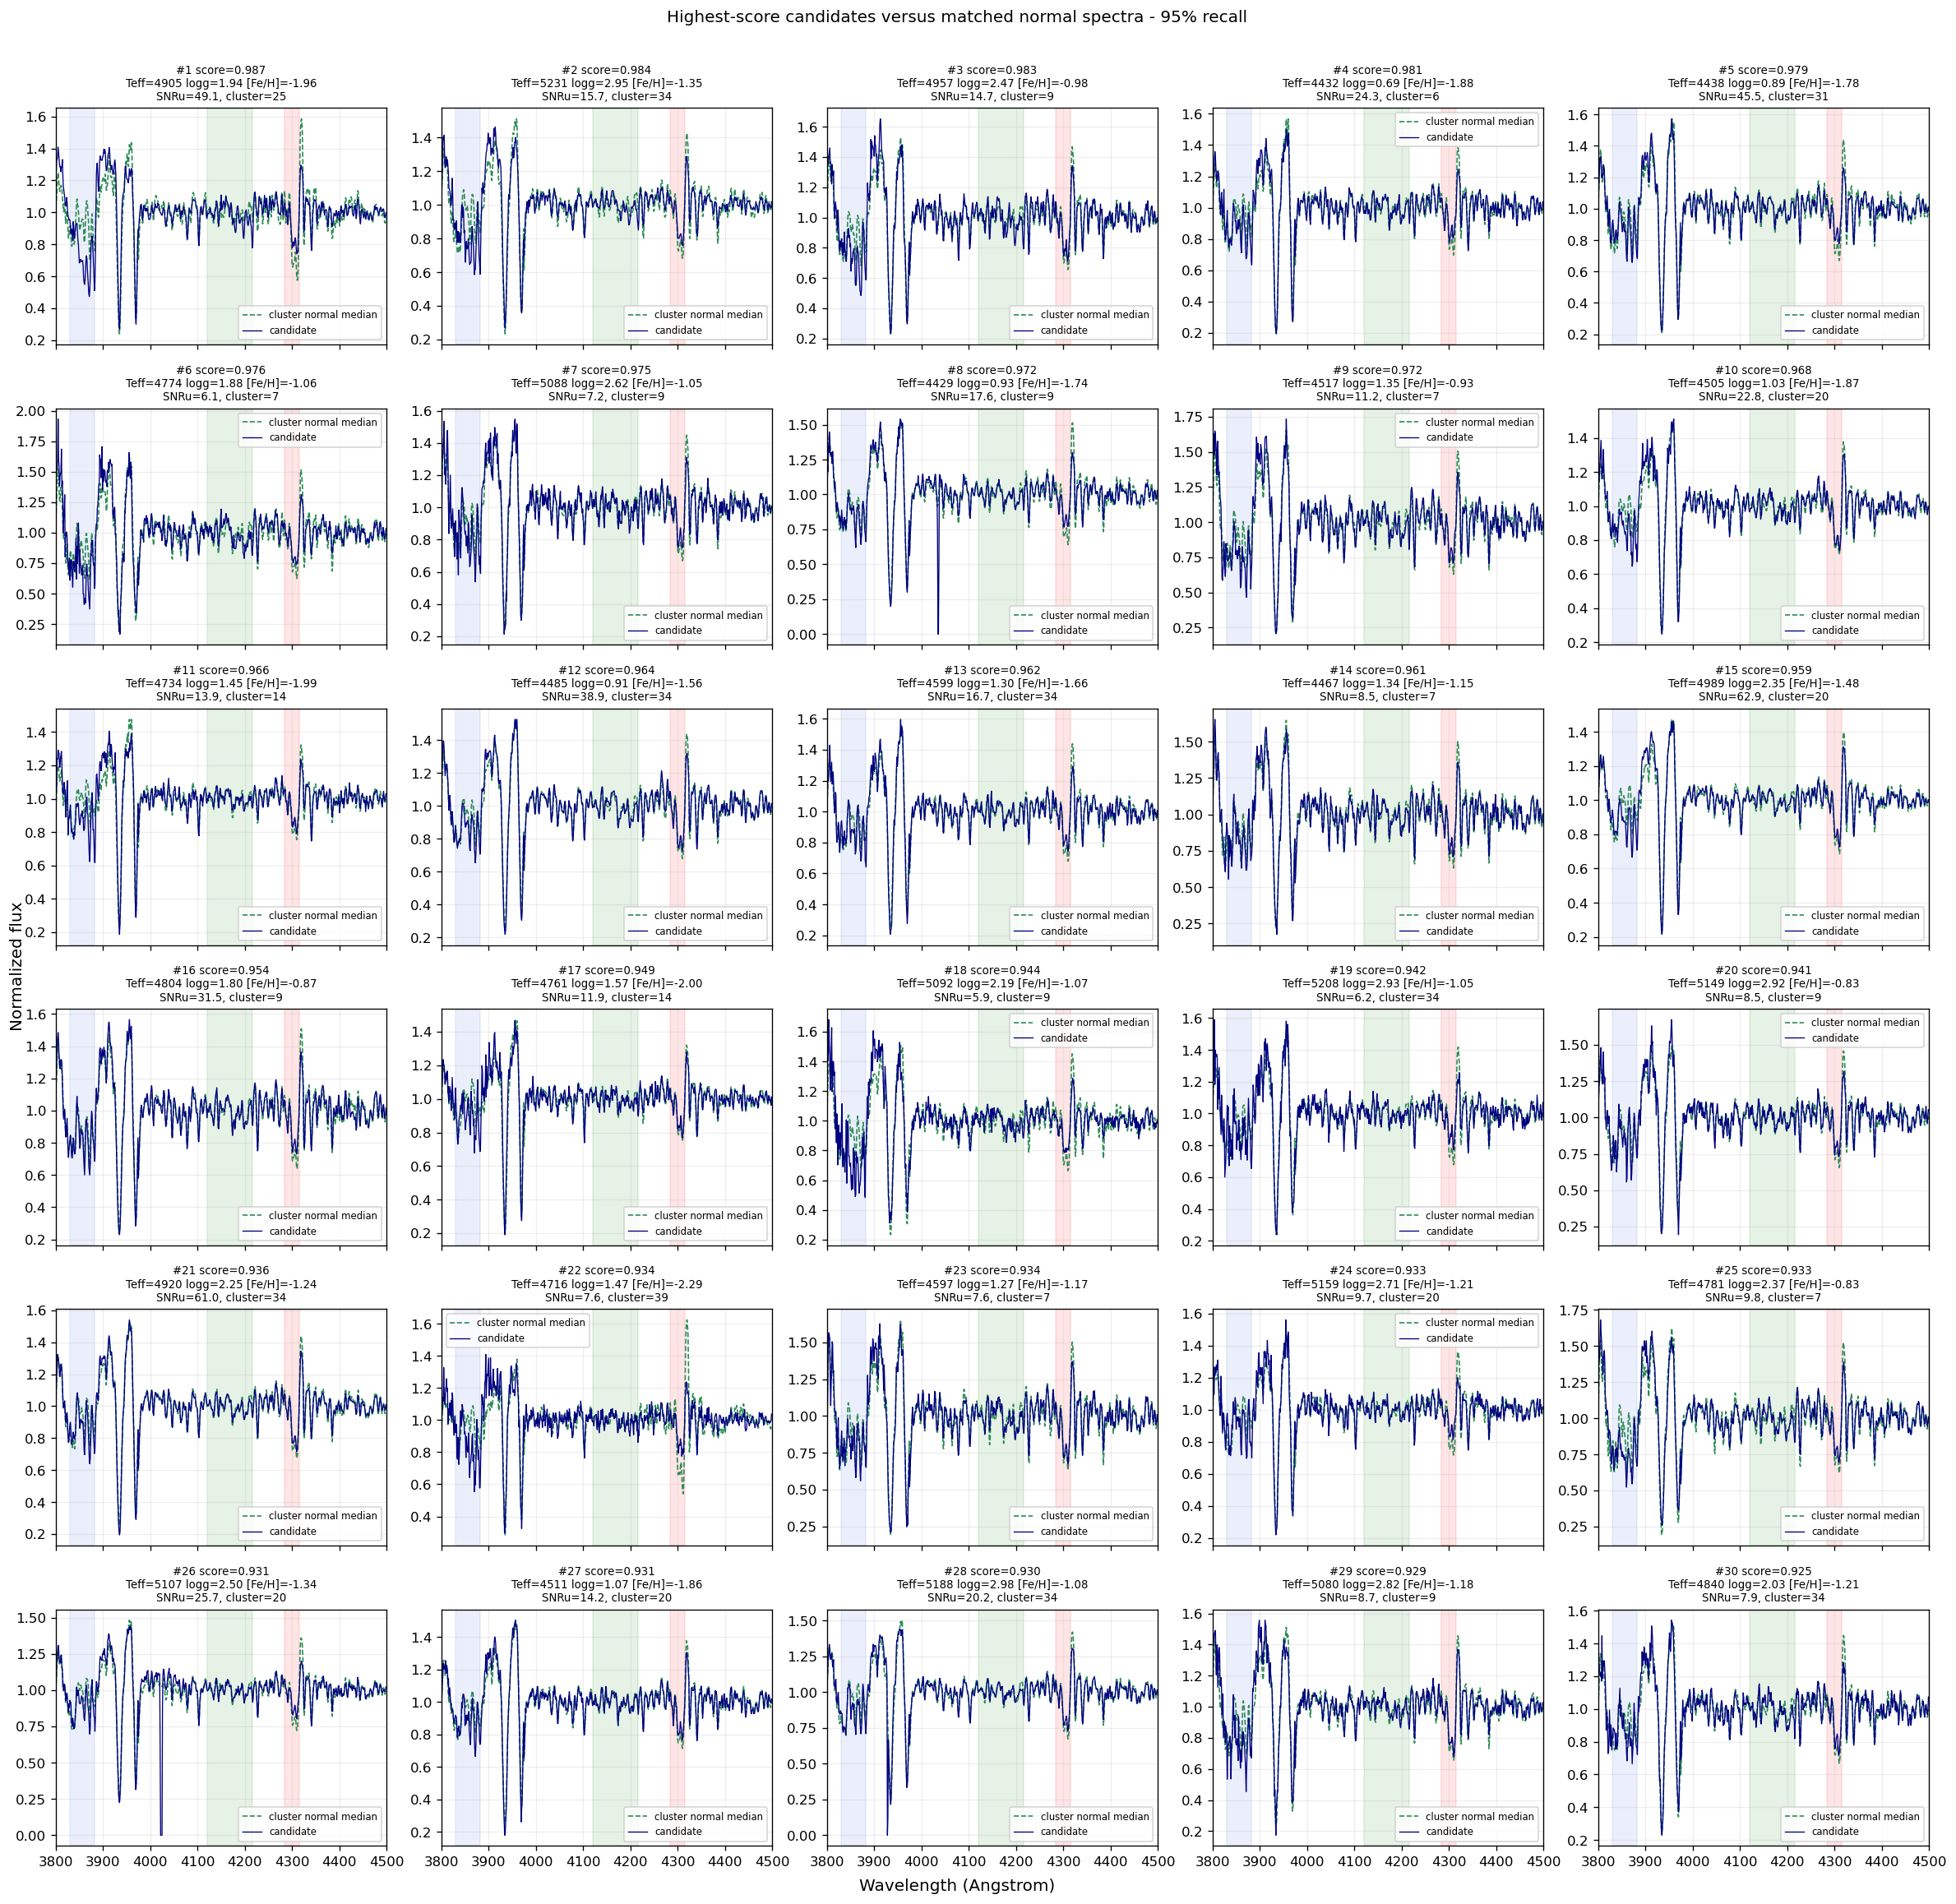

candidates drawn in the figure: 30


,candidate_rank,uid,xgb_pu_score,xgb_pu_repeat_std,teff,logg,feh,snru,masked_cluster_id
0,1,G14866615886127,0.986986,0.000705,4904.80,1.935,-1.957,49.10,25
1,2,L15071198679004,0.983976,0.004070,5230.59,2.954,-1.350,15.73,34
2,3,G14502126087737,0.982945,0.001469,4956.85,2.472,-0.984,14.73,9
3,4,G15296286229400,0.981443,0.006236,4431.64,0.688,-1.877,24.29,6
4,5,G15801615940186,0.978856,0.005761,4437.85,0.890,-1.783,45.54,31
5,6,L15968094080310,0.976435,0.003912,4773.54,1.877,-1.065,6.13,7
6,7,G16354057494204,0.974535,0.001998,5088.23,2.619,-1.047,7.24,9
7,8,G16369423799359,0.972222,0.005472,4428.72,0.932,-1.744,17.60,9
8,9,G11164235221213,0.972085,0.004148,4517.39,1.354,-0.926,11.16,7
9,10,L14327934924837,0.968030,0.009914,4504.52,1.026,-1.868,22.75,20


In [9]:
line_dir_out = RESULTS_DIR / recall_tag(result_95["config"].target_recall) / ("smoke" if QUICK else "formal")

drawn_95 = cplot.plot_top_candidate_spectra(
    all_scores_95,
    np.asarray(data["X_clean"]),
    common_wave,
    candidates_95,
    line_dir_out / f"top{TOP_N}_candidate_spectra_95.png",
    top_n=TOP_N,
    title="Highest-score candidates versus matched normal spectra - 95% recall",
)

print("candidates drawn in the figure:", len(drawn_95))
display(
    candidates_95.sort_values("xgb_pu_score", ascending=False)
    .head(TOP_N)[
        ["candidate_rank", "uid", "xgb_pu_score", "xgb_pu_repeat_std", "teff", "logg", "feh", "snru", "masked_cluster_id"]
    ]
    .reset_index(drop=True)
)

## 9. 阈值—召回—候选数量权衡

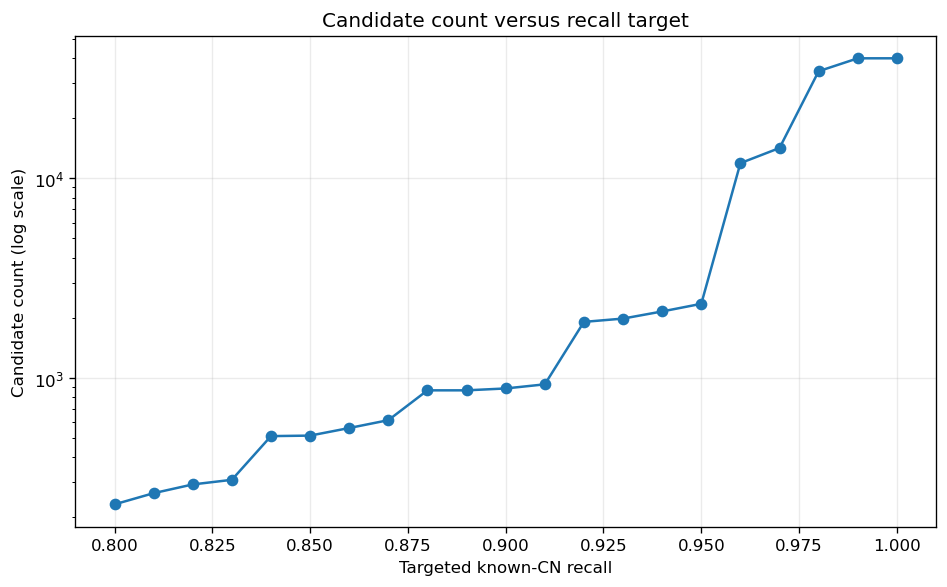

,target_recall,required_known,achieved_known_recall,threshold,candidate_count
0,0.80,73,0.802198,0.396436,232
1,0.90,82,0.901099,0.137546,884
2,0.95,87,0.956044,0.055130,2348
3,0.99,91,1.000000,0.005286,39924
4,1.00,91,1.000000,0.005286,39924


In [10]:
known_scores = known_90["xgb_pu_score"].to_numpy()
unlabeled_scores = all_scores_90.loc[all_scores_90["label"] == -1, "xgb_pu_score"].to_numpy()
sensitivity = cplot.plot_threshold_sensitivity(known_scores, unlabeled_scores)
display(sensitivity[sensitivity["target_recall"].isin([0.80, 0.85, 0.90, 0.95, 0.99, 1.00])].reset_index(drop=True))

## 10. 导出清单与结论

In [11]:
files = sorted(p.relative_to(RESULTS_DIR).as_posix() for p in RESULTS_DIR.rglob("*") if p.is_file())
export_table = pd.DataFrame({"exported file": files, "size (KB)": [round((RESULTS_DIR / f).stat().st_size / 1024, 1) for f in files]})
display(export_table)
print("Total exported:", round(sum((RESULTS_DIR / f).stat().st_size for f in files) / 1024 / 1024, 2), "MB")
print()
print("Per line the export is limited to: candidate table, known-CN table, summary JSON,")
print("compact array archive and the top-30 candidate spectrum figure.")

,exported file,size (KB)
0,recall90/formal/crossfit_arrays_recall90.npz,2111.8
1,recall90/formal/crossfit_candidates_recall90.csv,3093.0
2,recall90/formal/crossfit_known_cn_recall90.csv,318.3
3,recall90/formal/crossfit_summary_recall90.json,1.2
4,recall90/formal/crossfit_training_history_reca...,3.2
5,recall90/formal/top30_candidate_spectra_90.png,2229.2
6,recall95/formal/crossfit_arrays_recall95.npz,2111.8
7,recall95/formal/crossfit_candidates_recall95.csv,8221.2
8,recall95/formal/crossfit_known_cn_recall95.csv,318.2
9,recall95/formal/crossfit_summary_recall95.json,1.2


Total exported: 20.16 MB

Per line the export is limited to: candidate table, known-CN table, summary JSON,
compact array archive and the top-30 candidate spectrum figure.


### 结论与使用建议

- 主结果取 **90% 召回线**：`N_candidates @ Recall>=90%` 是主选择指标，ROC-AUC / PR-AUC 只作辅助。
- **务必同时报告三次重复的候选数量与阈值**，不要只报均值；若重复波动大，应报告「重复间都被选中的交集」作为高置信核心集。
- 候选表已按分数降序并带 `candidate_rank`，可直接与其它方法（指数法、面积法、图半监督）做交集/差集。
- `xgb_pu_score` 用于**排序**，不要解释为概率；跨配置比较时应重新按各自已知星分数标定阈值。